# Classification

## Setup

In [66]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as st
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

## Load Data

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
X, y = mnist["data"], mnist["target"]

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42
)

## CNN


In [1]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

In [2]:
# Load Data
(xtr, ytr), (xte, yte) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
# normalize between [0, 1]
xtr = (xtr/255.0).astype("float32")[...,None]
xte = (xte/255.0).astype("float32")[...,None]

In [12]:
# create train and testy tf.data
BATCH = 128
ds_train = tf.data.Dataset.from_tensor_slices((xtr, ytr)).shuffle(60000).batch(BATCH).prefetch(tf.data.AUTOTUNE)
ds_test = tf.data.Dataset.from_tensor_slices((xte, yte)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

In [13]:
# Augmentation
aug = tf.keras.Sequential([
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomRotation(0.08),
])

In [14]:
# Model (small but strong)
def make_model():
    input = layers.Input((28,28,1))
    x = aug(input)
    x = layers.Conv2D(32,3,padding="same",activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32,3,padding="same",activation="relu")(x)
    x = layers.MaxPool2D()(x); x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64,3,padding="same",activation="relu")(x);
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64,3,padding="same",activation="relu")(x)
    x = layers.MaxPool2D()(x);
    x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128,activation="relu")(x); x = layers.Dropout(0.5)(x)
    output = layers.Dense(10,activation="softmax")(x)
    m = models.Model(input,output)
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

model = make_model()

### Train and inspect one batch

In [15]:
xb, yb = next(iter(ds_train))
loss, acc = model.train_on_batch(xb, yb)
print(f"After 1 batch -> loss:{loss:.4f}, acc:{acc:.4f}")

After 1 batch -> loss:3.8761, acc:0.1094


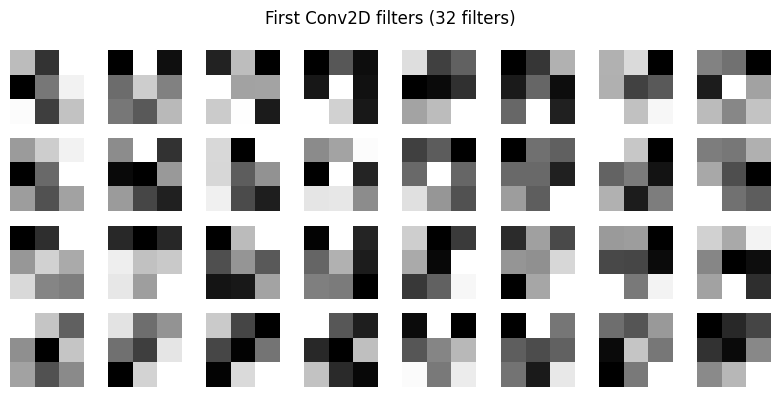

In [17]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# find first Conv2D layer
conv_layer = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        conv_layer = layer
        break

if conv_layer is None:
    raise ValueError("No Conv2D layer found in model!")

# get weights
w = conv_layer.get_weights()[0]  # shape: (kernel_h, kernel_w, in_channels, out_channels)

# normalize for display
wmin, wmax = w.min(), w.max()
w_vis = (w - wmin) / (wmax - wmin + 1e-8)

# plot up to 32 filters
n_filters = min(w_vis.shape[-1], 32)

plt.figure(figsize=(8,4))
for i in range(n_filters):
    plt.subplot(4,8,i+1)
    # show channel 0 (MNIST is grayscale so in_channels = 1)
    plt.imshow(w_vis[:,:,0,i], cmap="gray")
    plt.axis("off")

plt.suptitle(f"First Conv2D filters ({n_filters} filters)")
plt.tight_layout()
plt.show()


In [18]:
for i, l in enumerate(model.layers):
    print(i, l.name, type(l), l.weights and len(l.get_weights()))

0 input_layer_1 <class 'keras.src.layers.core.input_layer.InputLayer'> []
1 sequential_1 <class 'keras.src.models.sequential.Sequential'> []
2 conv2d <class 'keras.src.layers.convolutional.conv2d.Conv2D'> 2
3 batch_normalization <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'> 4
4 conv2d_1 <class 'keras.src.layers.convolutional.conv2d.Conv2D'> 2
5 max_pooling2d <class 'keras.src.layers.pooling.max_pooling2d.MaxPooling2D'> []
6 dropout <class 'keras.src.layers.regularization.dropout.Dropout'> []
7 conv2d_2 <class 'keras.src.layers.convolutional.conv2d.Conv2D'> 2
8 batch_normalization_1 <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'> 4
9 conv2d_3 <class 'keras.src.layers.convolutional.conv2d.Conv2D'> 2
10 max_pooling2d_1 <class 'keras.src.layers.pooling.max_pooling2d.MaxPooling2D'> []
11 dropout_1 <class 'keras.src.layers.regularization.dropout.Dropout'> []
12 flatten <class 'keras.src.layers.reshaping.flatten.Flatten'> []
13

### Train the rest

In [20]:
# Train (with val split, early stop, LR schedule)
cb = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor="val_loss")
]
# history = model.fit(ds_train, epochs=10, validation_data=ds_test, verbose=2)
hist = model.fit(ds_train, epochs=15, validation_data=ds_test, callbacks=cb, verbose=2)

Epoch 1/15
469/469 - 11s - 23ms/step - accuracy: 0.6974 - loss: 0.8629 - val_accuracy: 0.9798 - val_loss: 0.1493 - learning_rate: 1.0000e-03
Epoch 2/15
469/469 - 8s - 18ms/step - accuracy: 0.8567 - loss: 0.4107 - val_accuracy: 0.9713 - val_loss: 0.0937 - learning_rate: 1.0000e-03
Epoch 3/15
469/469 - 8s - 17ms/step - accuracy: 0.9135 - loss: 0.2669 - val_accuracy: 0.9870 - val_loss: 0.0396 - learning_rate: 1.0000e-03
Epoch 4/15
469/469 - 8s - 17ms/step - accuracy: 0.9454 - loss: 0.1807 - val_accuracy: 0.9903 - val_loss: 0.0328 - learning_rate: 1.0000e-03
Epoch 5/15
469/469 - 8s - 17ms/step - accuracy: 0.9597 - loss: 0.1346 - val_accuracy: 0.9922 - val_loss: 0.0239 - learning_rate: 1.0000e-03
Epoch 6/15
469/469 - 8s - 17ms/step - accuracy: 0.9686 - loss: 0.1116 - val_accuracy: 0.9889 - val_loss: 0.0343 - learning_rate: 1.0000e-03
Epoch 7/15
469/469 - 8s - 17ms/step - accuracy: 0.9725 - loss: 0.0990 - val_accuracy: 0.9893 - val_loss: 0.0297 - learning_rate: 1.0000e-03
Epoch 8/15
469/469 

In [ ]:


# 5) Test accuracy
test_acc = model.evaluate(ds_test, verbose=0)[1]
print("Test accuracy:", round(float(test_acc), 4))

# 6) Confusion matrix
yp = model.predict(ds_test, verbose=0)
y_pred = yp.argmax(axis=1)
fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay.from_predictions(yte, y_pred, ax=ax, values_format='d')
ax.set_title("CNN Confusion Matrix"); plt.tight_layout(); plt.show()

# 7) Show 16 mistakes
mis = np.where(y_pred != yte)[0]
if len(mis) > 0:
    pick = np.random.RandomState(42).choice(mis, size=min(16, len(mis)), replace=False)
    plt.figure(figsize=(8,8))
    for i, idx in enumerate(pick, 1):
        plt.subplot(4,4,i)
        plt.imshow(xte[idx].squeeze(), cmap="gray")
        plt.title(f"pred:{int(y_pred[idx])} / true:{int(yte[idx])}")
        plt.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No mistakes on test set (rare, but nice!).")


In [ ]:
# Subsample
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import scipy.stats as st
from sklearn.base import clone

# 1) stratified subset (e.g., 20k rows)
sss = StratifiedShuffleSplit(n_splits=1, test_size=50000, random_state=42)
(tr_idx, _), = sss.split(X_train, y_train)
X_sub, y_sub = X_train[tr_idx], y_train[tr_idx]

# 2) random search on subset
rf = RandomForestClassifier(random_state=42, n_jobs=1)  # avoid nested parallelism
param_dist = {
    "n_estimators": st.randint(100, 400),
    "max_depth": [None, 20, 40],
    "max_features": ["sqrt", 0.2],
    "min_samples_leaf": [1, 2],
}
rs = RandomizedSearchCV(rf, param_dist, n_iter=20, cv=3, n_jobs=-1, verbose=1, scoring="accuracy")
rs.fit(X_sub, y_sub)

# 3) refit best params on the full training set
best_rf = clone(rs.best_estimator_)
best_rf.set_params(n_jobs=-1)
best_rf.fit(X_train, y_train)
print("Test acc:", best_rf.score(X_test, y_test))
